<a href="https://colab.research.google.com/github/nigamshivanshu/Online-Payments-Fraud-Detection-with-Machine-Learning/blob/develop/Online_Payments_Fraud_Detection_with_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://user-images.githubusercontent.com/86102231/221410144-2c07a913-f8d8-4a2f-829d-22749bfce53e.png">

# 💳 Online Payments Fraud Detection with Machine Learning

## 📌 Introduction

#### Fraudulent financial transactions are a significant challenge in the digital payments ecosystem. This project aims to develop a machine learning model capable of detecting fraudulent mobile money transactions using the **PaySim synthetic financial dataset**. The dataset is based on real mobile transaction patterns and includes simulated fraudulent behavior, providing a realistic testbed for fraud detection algorithms.

#### Detecting fraud is crucial for financial institutions, fintech companies, and end-users to prevent losses and build trust in digital payment systems.

#### Through this project, we will apply several machine learning algorithms, compare their performance, and identify the best model to flag potential frauds in real-time transactions.


## 🎯 Objective

### The primary goal of this project is to:

####- Analyze mobile money transaction data.
####- Identify patterns and anomalies in transaction behaviors.
####- Build and compare multiple machine learning models for **fraud detection**.
####- Evaluate the performance of each model based on accuracy, recall, precision, F1-score, and ROC-AUC.
####- Highlight the best-performing model for real-world deployment.

####🛑 Note: This dataset simulates fraud behavior by injecting fraudulent transactions into realistic transaction patterns. We must avoid data leakage, especially from columns directly influenced by labels (as warned in the dataset's documentation).


## 📚 About the Dataset

This dataset was generated using **PaySim**, a simulator built using aggregated data from a mobile money service provider. Due to the sensitive nature of financial transactions, PaySim creates synthetic yet realistic data for research and fraud detection testing.

### Key Features:
- `step`: Hour-wise time steps (Total of 744 steps = 30 days)
- `type`: Type of transaction (e.g., CASH-IN, TRANSFER, PAYMENT)
- `amount`: Transaction amount
- `nameOrig` & `nameDest`: IDs for sender and receiver
- `oldbalanceOrg` & `newbalanceOrig`: Sender balance before and after
- `oldbalanceDest` & `newbalanceDest`: Receiver balance before and after
- `isFraud`: `1` indicates fraudulent transaction
- `isFlaggedFraud`: `1` flags potentially illegal transactions (amount > 200,000)

🔐 **Important Note**: Columns like `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, and `newbalanceDest` should be excluded for training, as flagged in the dataset's documentation to prevent data leakage.


In [1]:
# 📥 Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "PS_20174392719_1491204439457_log.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ealaxi/paysim1",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



In [3]:
print("First 5 records 🔽")
df.head()

First 5 records 🔽


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 🧹 Data Preprocessing

We'll first inspect the dataset, check for missing values, and drop unnecessary columns that may cause data leakage during training.


In [4]:
# Check basic info
df.info()

# Check for nulls
print(df.isnull().sum())

# Drop columns that should not be used for training due to potential data leakage
df_cleaned = df.drop(['nameOrig', 'nameDest', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], axis=1)

# Encode the 'type' column
df_cleaned['type'] = LabelEncoder().fit_transform(df_cleaned['type'])

# Check class distribution
print(df_cleaned['isFraud'].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


## 📊 Exploratory Data Analysis (EDA)

Let’s explore the transaction types, the distribution of fraudulent vs non-fraudulent transactions, and transaction amount patterns.


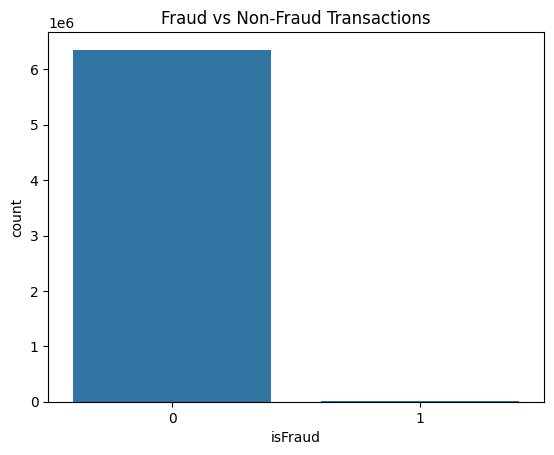

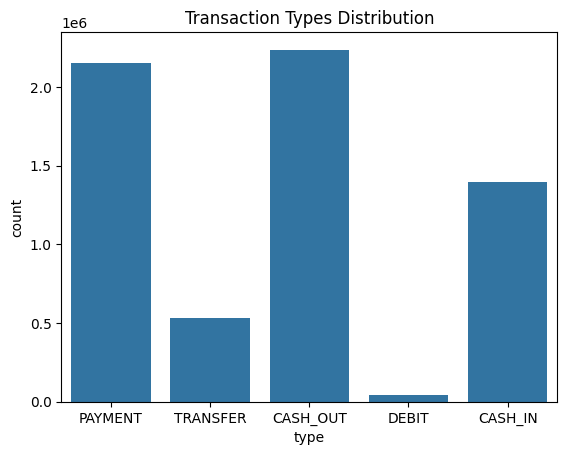

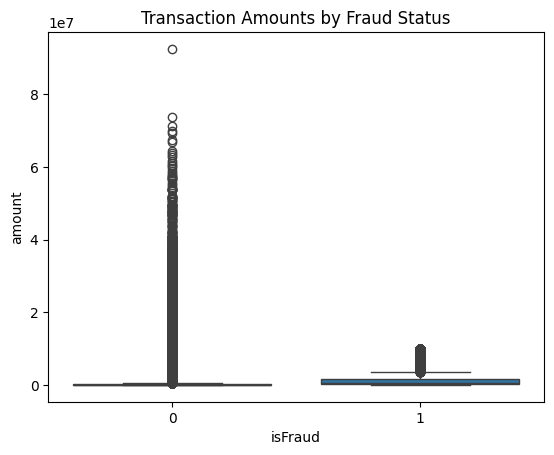

In [5]:
# Fraud vs Non-Fraud count
sns.countplot(x='isFraud', data=df_cleaned)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

# Transaction types
sns.countplot(x='type', data=df)
plt.title("Transaction Types Distribution")
plt.show()

# Distribution of transaction amounts by fraud
sns.boxplot(x='isFraud', y='amount', data=df_cleaned)
plt.title("Transaction Amounts by Fraud Status")
plt.show()


## 🛠️ Feature Engineering

We already dropped columns that can cause data leakage and encoded the `type` feature. Now we’ll proceed with splitting the data and scaling.


In [6]:
# Define X and y
X = df_cleaned.drop(['isFraud', 'isFlaggedFraud'], axis=1)
y = df_cleaned['isFraud']

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)


## 🤖 Model Building & Evaluation

We will train multiple ML algorithms and compare their performance:

1. Logistic Regression  
2. Decision Tree  
3. Random Forest  
4. XGBoost  
5. LightGBM  
6. CatBoost  
7. Support Vector Machine  
8. K-Nearest Neighbors


In [10]:
pip install lightgbm catboost xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 3.3 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0),
    "Support Vector Machine": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

#training & evaluation for all models
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "report": classification_report(y_test, y_pred, output_dict=True),
        "roc_auc": roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }

print("\n✅ All models trained and evaluated.")


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...
Training Support Vector Machine...
